# HR Employee Attrition - Exploratory Data Analysis

**Objective:**

To clean and explore the HR employee dataset in order to assess data quality and identify the 
key factors most strongly associated with employee attrition — including overtime, job 
satisfaction, work-life balance, promotion history, and income — so the organization can 
prioritize targeted, evidence-based retention strategies instead of broad, unfocused interventions.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

# 1. Load & Inspect data

In [5]:
df = pd.read_csv("hr_attrition_light_clean.csv")
print(df.shape)
df.head()

(1212, 23)


,EmployeeID,Age,Gender,Department,JobRole,EducationField,MaritalStatus,BusinessTravel,DistanceFromHome,MonthlyIncome,...,TotalWorkingYears,NumCompaniesWorked,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,OverTime,TrainingTimesLastYear,Attrition
0,199,39,Female,research & development,Manager,Technical Degree,Divorced,Travel_Rarely,5,15066.0,...,16,7,3.0,1,3,1,3,Yes,0,No
1,1062,37,Male,Research & Development,Research Scientist,Marketing,Divorced,Travel_Frequently,13,NaN,...,26,0,2.0,3,4,2,2,No,3,No
2,250,56,Male,Research & Development,Research Scientist,Life Sciences,Married,Travel_Rarely,23,16545.0,...,34,2,1.0,1,2,1,2,No,2,no
3,904,32,Male,Sales,Laboratory Technician,Life Sciences,Divorced,Travel_Frequently,13,9390.0,...,17,7,2.0,2,1,4,1,Yes,5,No
4,98,27,Male,Sales,Research Director,Marketing,Divorced,Travel_Rarely,19,8234.0,...,20,0,3.0,4,3,2,1,Yes,1,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               1212 non-null   int64  
 1   Age                      1212 non-null   int64  
 2   Gender                   1212 non-null   object 
 3   Department               1212 non-null   object 
 4   JobRole                  1212 non-null   object 
 5   EducationField           1175 non-null   object 
 6   MaritalStatus            1212 non-null   object 
 7   BusinessTravel           1212 non-null   object 
 8   DistanceFromHome         1212 non-null   int64  
 9   MonthlyIncome            1164 non-null   float64
 10  PercentSalaryHike        1212 non-null   int64  
 11  YearsAtCompany           1212 non-null   int64  
 12  YearsSinceLastPromotion  1212 non-null   int64  
 13  TotalWorkingYears        1212 non-null   int64  
 14  NumCompaniesWorked      

In [4]:
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeID,1212.0,NaN,NaN,NaN,599.543729,346.797183,1.0,299.75,598.5,899.25,1200.0
Age,1212.0,NaN,NaN,NaN,38.60231,12.079981,18.0,28.0,38.5,49.0,59.0
Gender,1212,4,Female,621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,1212,9,Research & Development,638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
JobRole,1212,9,Human Resources,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationField,1175,6,Human Resources,230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,1212,3,Single,425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1212,3,Travel_Rarely,729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1212.0,NaN,NaN,NaN,15.138614,8.345488,1.0,8.0,15.0,22.0,29.0
MonthlyIncome,1164.0,NaN,NaN,NaN,11011.579038,5187.003732,2014.0,6625.0,10999.0,15462.0,19995.0


## 2. Data Quality check

In [5]:
df.isnull().sum()

EmployeeID                  0
Age                         0
Gender                      0
Department                  0
JobRole                     0
EducationField             37
MaritalStatus               0
BusinessTravel              0
DistanceFromHome            0
MonthlyIncome              48
PercentSalaryHike           0
YearsAtCompany              0
YearsSinceLastPromotion     0
TotalWorkingYears           0
NumCompaniesWorked          0
JobSatisfaction            36
EnvironmentSatisfaction     0
WorkLifeBalance             0
JobInvolvement              0
PerformanceRating           0
OverTime                    0
TrainingTimesLastYear       0
Attrition                   0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(10)

In [9]:
df["EmployeeID"].duplicated().sum()

np.int64(12)

In [10]:
df.dtypes

EmployeeID                   int64
Age                          int64
Gender                      object
Department                  object
JobRole                     object
EducationField              object
MaritalStatus               object
BusinessTravel              object
DistanceFromHome             int64
MonthlyIncome              float64
PercentSalaryHike            int64
YearsAtCompany               int64
YearsSinceLastPromotion      int64
TotalWorkingYears            int64
NumCompaniesWorked           int64
JobSatisfaction            float64
EnvironmentSatisfaction      int64
WorkLifeBalance              int64
JobInvolvement               int64
PerformanceRating            int64
OverTime                    object
TrainingTimesLastYear        int64
Attrition                   object
dtype: object

In [11]:
df["Department"].value_counts()

Department
Research & Development      638
Sales                       409
Human Resources             103
research & development       20
 Research & Development      15
sales                        14
 Sales                       11
 Human Resources              1
human resources               1
Name: count, dtype: int64

In [12]:
df["Gender"].value_counts()

Gender
Female    621
Male      572
F          11
M           8
Name: count, dtype: int64

In [13]:
df["JobRole"].value_counts()

JobRole
Human Resources              156
Manager                      153
Sales Representative         143
Sales Executive              140
Research Director            135
Laboratory Technician        128
Research Scientist           125
Manufacturing Director       118
Healthcare Representative    114
Name: count, dtype: int64

In [14]:
df["EducationField"].value_counts(dropna = False)

EducationField
Human Resources     230
Technical Degree    205
Marketing           197
Medical             196
Life Sciences       176
Other               171
NaN                  37
Name: count, dtype: int64

In [15]:
df["MaritalStatus"].value_counts()

MaritalStatus
Single      425
Married     413
Divorced    374
Name: count, dtype: int64

In [16]:
df["BusinessTravel"].value_counts()

BusinessTravel
Travel_Rarely        729
Travel_Frequently    297
Non-Travel           186
Name: count, dtype: int64

In [17]:
df["OverTime"].value_counts()

OverTime
No     844
Yes    368
Name: count, dtype: int64

In [18]:
df["Attrition"].value_counts()

Attrition
No     956
Yes    195
no      49
yes     12
Name: count, dtype: int64

In [19]:
df[["Age",
    "DistanceFromHome", "MonthlyIncome",
    "PercentSalaryHike","YearsAtCompany",
    "YearsSinceLastPromotion","TotalWorkingYears",
    "NumCompaniesWorked","TrainingTimesLastYear"]].describe()

,Age,DistanceFromHome,MonthlyIncome,PercentSalaryHike,YearsAtCompany,YearsSinceLastPromotion,TotalWorkingYears,NumCompaniesWorked,TrainingTimesLastYear
count,1212.000000,1212.000000,1164.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000
mean,38.602310,15.138614,11011.579038,17.075908,11.806106,6.827558,20.209571,3.915017,2.499175
std,12.079981,8.345488,5187.003732,4.318552,7.232452,4.429180,11.491812,2.575410,1.726320
min,18.000000,1.000000,2014.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,8.000000,6625.000000,13.000000,5.000000,3.000000,10.000000,2.000000,1.000000
50%,38.500000,15.000000,10999.000000,17.000000,11.000000,7.000000,21.000000,4.000000,3.000000
75%,49.000000,22.000000,15462.000000,21.000000,18.000000,11.000000,30.000000,6.000000,4.000000
max,59.000000,29.000000,19995.000000,24.000000,24.000000,14.000000,39.000000,8.000000,5.000000


In [20]:
df[['JobSatisfaction',
    'EnvironmentSatisfaction',
    'WorkLifeBalance',
    'JobInvolvement',
    'PerformanceRating']].describe()

,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,1176.000000,1212.000000,1212.000000,1212.000000,1212.000000
mean,2.506803,2.478548,2.496700,2.488449,2.524752
std,1.133605,1.092139,1.128048,1.119174,1.137985
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,1.000000,1.000000,1.000000
50%,3.000000,2.000000,2.000000,2.000000,3.000000
75%,4.000000,3.000000,4.000000,3.000000,4.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000


In [21]:
df[df["Age"] < 18]

,EmployeeID,Age,Gender,Department,JobRole,EducationField,MaritalStatus,BusinessTravel,DistanceFromHome,MonthlyIncome,...,TotalWorkingYears,NumCompaniesWorked,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,OverTime,TrainingTimesLastYear,Attrition


In [22]:
df[df["MonthlyIncome"] < 0]

,EmployeeID,Age,Gender,Department,JobRole,EducationField,MaritalStatus,BusinessTravel,DistanceFromHome,MonthlyIncome,...,TotalWorkingYears,NumCompaniesWorked,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,OverTime,TrainingTimesLastYear,Attrition


**Observation**
- The dataset contains 1,212 records and 23 columns.
- EmployeeID has 12 duplicates
- EducationField has 37 missing values.
- MonthlyIncome has  48 missing values.
- JobSatisfaction has 36 missing values.
- Department contains inconsistent formatting.
- Gender contains inconsistent categories.
- Attrition has inconsistent casing.

## 3. Data Cleaning

In [23]:
dup_ids = df[df["EmployeeID"].duplicated(keep = False)]
dup_ids.sort_values("EmployeeID") 

,EmployeeID,Age,Gender,Department,JobRole,EducationField,MaritalStatus,BusinessTravel,DistanceFromHome,MonthlyIncome,...,TotalWorkingYears,NumCompaniesWorked,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,OverTime,TrainingTimesLastYear,Attrition
950,12,38,Male,Human Resources,Healthcare Representative,Medical,Single,Travel_Rarely,29,17251.0,...,14,1,2.0,4,2,4,1,No,5,No
901,12,38,Male,Human Resources,Healthcare Representative,Medical,Single,Travel_Rarely,29,17251.0,...,14,1,2.0,4,2,4,1,No,5,No
315,35,18,Female,Research & Development,Sales Executive,Technical Degree,Married,Travel_Rarely,20,6487.0,...,6,1,2.0,2,3,1,1,No,3,No
386,35,18,Female,Research & Development,Sales Executive,Technical Degree,Married,Travel_Rarely,20,6487.0,...,6,1,2.0,2,3,1,1,No,3,No
296,107,19,Female,Research & Development,Manager,Life Sciences,Single,Travel_Rarely,26,10653.0,...,4,7,4.0,1,1,4,1,No,2,Yes
610,107,19,Female,research & development,Manager,Life Sciences,Single,Travel_Rarely,26,10653.0,...,4,7,4.0,1,1,4,1,No,2,Yes
139,236,46,Female,Research & Development,Manufacturing Director,Marketing,Married,Non-Travel,15,19393.0,...,25,2,4.0,1,2,1,4,No,2,No
711,236,46,Female,Research & Development,Manufacturing Director,Marketing,Married,Non-Travel,15,19393.0,...,25,2,4.0,1,2,1,4,No,2,No
977,313,57,Male,Research & Development,Sales Executive,NaN,Single,Travel_Rarely,27,18764.0,...,2,8,2.0,3,4,4,1,No,0,No
464,313,57,Male,Research & Development,Sales Executive,NaN,Single,Travel_Rarely,27,18764.0,...,2,8,2.0,3,4,4,1,No,0,No


In [24]:
df["Department"] = df["Department"].str.strip().str.title()

In [25]:
df["Department"].value_counts()

Department
Research & Development    673
Sales                     434
Human Resources           105
Name: count, dtype: int64

In [26]:
df["Gender"] = df["Gender"].replace({
    "M": "Male",
    "F": "Female"})

In [27]:
df["Gender"].value_counts()

Gender
Female    632
Male      580
Name: count, dtype: int64

In [28]:
df["Attrition"] = df["Attrition"].str.capitalize()

In [29]:
df["Attrition"].value_counts()

Attrition
No     1005
Yes     207
Name: count, dtype: int64

In [30]:
df = df.drop_duplicates().copy()
df.duplicated().sum()

np.int64(0)

In [32]:
#filling missing values of Education field
df["EducationField"] = df["EducationField"].fillna("Unknown")

In [33]:
df["EducationField"].isnull().sum()

np.int64(0)

In [34]:
# imputing MonthlyIncome
df["MonthlyIncome"] = df.groupby(["Department", "JobRole"])["MonthlyIncome"].transform(lambda x : x.fillna(x.mean()))

In [36]:
df["MonthlyIncome"].isnull().sum()

np.int64(0)

In [37]:
df["JobSatisfaction"] = df["JobSatisfaction"].fillna(df["JobSatisfaction"].median())

In [38]:
df["JobSatisfaction"].isnull().sum()

np.int64(0)

In [39]:
# Final verifcation
df.isnull().sum()

EmployeeID                 0
Age                        0
Gender                     0
Department                 0
JobRole                    0
EducationField             0
MaritalStatus              0
BusinessTravel             0
DistanceFromHome           0
MonthlyIncome              0
PercentSalaryHike          0
YearsAtCompany             0
YearsSinceLastPromotion    0
TotalWorkingYears          0
NumCompaniesWorked         0
JobSatisfaction            0
EnvironmentSatisfaction    0
WorkLifeBalance            0
JobInvolvement             0
PerformanceRating          0
OverTime                   0
TrainingTimesLastYear      0
Attrition                  0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df["Gender"].unique(), df["Department"].unique(), df["Attrition"].unique()

(array(['Female', 'Male'], dtype=object),
 array(['Research & Development', 'Sales', 'Human Resources'], dtype=object),
 array(['No', 'Yes'], dtype=object))

In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeID,1200.0,600.500000,346.554469,1.0,300.75,600.5,900.25,1200.0
Age,1200.0,38.592500,12.075373,18.0,28.00,38.5,49.00,59.0
DistanceFromHome,1200.0,15.069167,8.340305,1.0,8.00,15.0,22.00,29.0
MonthlyIncome,1200.0,10989.587411,5086.940213,2014.0,6834.50,10923.0,15298.75,19995.0
PercentSalaryHike,1200.0,17.079167,4.312586,10.0,13.00,17.0,21.00,24.0
YearsAtCompany,1200.0,11.807500,7.233652,0.0,5.00,11.0,18.00,24.0
YearsSinceLastPromotion,1200.0,6.833333,4.429850,0.0,3.00,7.0,11.00,14.0
TotalWorkingYears,1200.0,20.231667,11.499994,0.0,10.00,21.0,30.00,39.0
NumCompaniesWorked,1200.0,3.918333,2.577570,0.0,2.00,4.0,6.00,8.0
JobSatisfaction,1200.0,2.521667,1.120525,1.0,1.00,3.0,3.00,4.0


## 4.Univariate Analysis

## Attrition

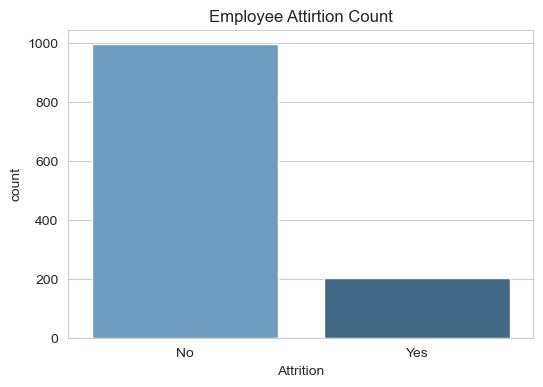

Attrition
No     83.0
Yes    17.0
Name: proportion, dtype: float64

In [47]:
plt.figure(figsize =(6,4))
sns.countplot(data = df, x = "Attrition", hue = "Attrition", palette = "Blues_d")
plt.title("Employee Attirtion Count")
plt.show()
df["Attrition"].value_counts(normalize = True) * 100

**Observation**
- 83% of employees have stayed and 17% left.
- The dataset is imbalanced towards `NO`, which is typical and expected for attrition data.
- This confirms that attrition is minority class problem.

**Business Insight**

Overall attrition looks healthy at 83%, but roughly 1 in 6 employees still leave.The remainder of this analysis investigates which factors are associated with that 17%, so retention efforts can be targeted rather than applied company-wide.

## OverTime

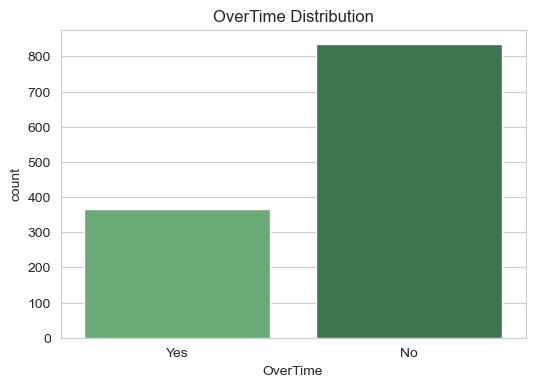

OverTime
No     69.5
Yes    30.5
Name: proportion, dtype: float64

In [52]:
plt.figure(figsize = (6,4))
sns.countplot(data = df, x="OverTime",hue = "OverTime", palette = "Greens_d")
plt.title("OverTime Distribution")
plt.show()
df["OverTime"].value_counts(normalize = True) * 100

**Observation**
- 69.5% of employees do not work overtime, while 30.5% do.
- The majority of the workforce keeps regular hours, with roughly 1 in 3 employees working overtime.

## Job Satisfaction 

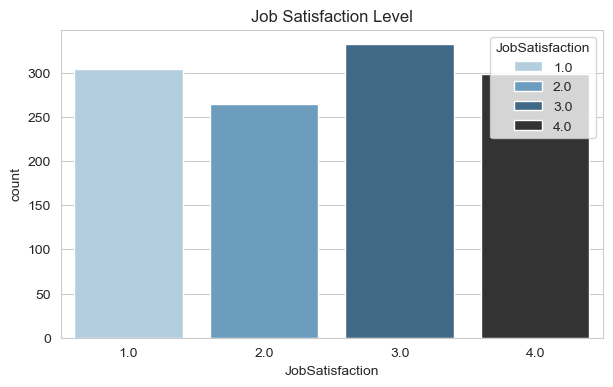

JobSatisfaction
1.0    25.333333
2.0    22.083333
3.0    27.666667
4.0    24.916667
Name: proportion, dtype: float64

In [54]:
sns.countplot(data = df, x = "JobSatisfaction", hue= "JobSatisfaction", palette ="Blues_d")
plt.title("Job Satisfaction Level")
plt.show()
df["JobSatisfaction"].value_counts(normalize =True).sort_index() *100

**Observation**
- Job satisfaction scores are fairly spread across all four levels, with no single level dominating.
- A meaningful share of employees report low satisfaction (levels 1-2), which is worth investigating against attrition next.

## Monthly Income

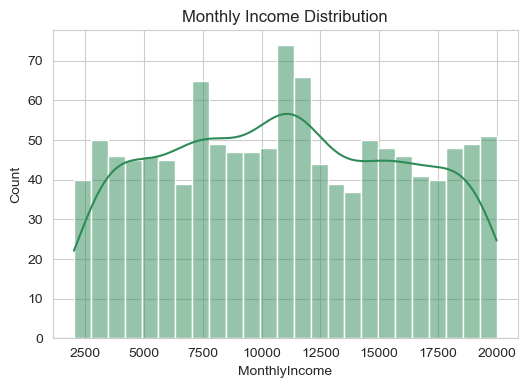

count     1200.000000
mean     10989.587411
std       5086.940213
min       2014.000000
25%       6834.500000
50%      10923.000000
75%      15298.750000
max      19995.000000
Name: MonthlyIncome, dtype: float64

In [55]:
plt.figure(figsize=(6,4))
sns.histplot(df["MonthlyIncome"], bins=25, kde=True, color="seagreen")
plt.title("Monthly Income Distribution")
plt.show()
df["MonthlyIncome"].describe()

**Interpretation**
- Income is spread fairly evenly from about ₹2,000 to ₹20,000, with no extreme concentration at either end.
- This spread reflects the range of job roles and seniority levels in the dataset.

## 5. Bivariate Analysis

``1. Does working overtime influence attrition?``

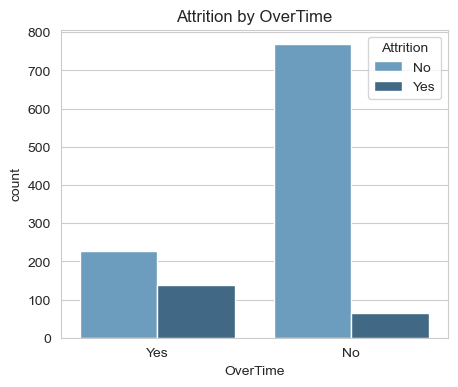

Attrition,No,Yes
OverTime,,
No,92.086331,7.913669
Yes,62.295082,37.704918


In [58]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="OverTime", hue="Attrition", palette="Blues_d")
plt.title("Attrition by OverTime")
plt.show()
pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100

**Interpretation**
- Employees who work overtime leave at a much higher rate (37.7%) than those who don't (7.9%).
- This is a large gap, suggesting overtime is strongly associated with attrition.

**Business Insight**

Overtime is strongly linked to attrition. The organization should review workload in high-overtime teams, consider additional hiring to ease the load, and track overtime hours as an early warning sign for employees at risk of leaving.

``2. Is job satisfaction related to attrition?``

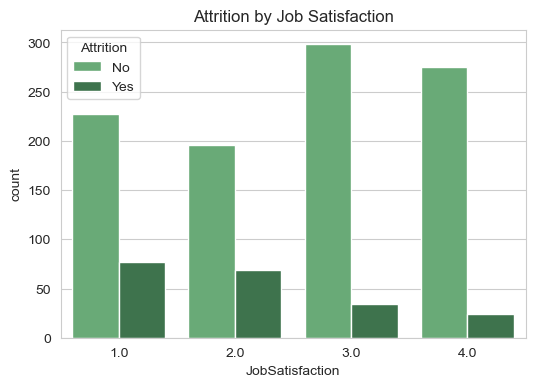

Attrition,No,Yes
JobSatisfaction,,
1.0,74.671053,25.328947
2.0,73.962264,26.037736
3.0,89.759036,10.240964
4.0,91.973244,8.026756


In [62]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition", palette="Greens_d")
plt.title("Attrition by Job Satisfaction")
plt.show()
pd.crosstab(df["JobSatisfaction"], df["Attrition"], normalize="index") * 100

**Interpretation**
- Attrition is noticeably higher among employees with low satisfaction scores compared to high satisfaction scores.
- Satisfaction shows a clear, graded relationship with attrition — the lower the score, the higher the attrition rate.

**Business Insight**
  
Job satisfaction is a strong, actionable signal. The organization should run regular satisfaction surveys, flag low scorers (1-2) for manager check-ins, and look into root causes like workload, recognition, or growth in teams with consistently low scores.

``3. Does work-life balance affect attrition?``

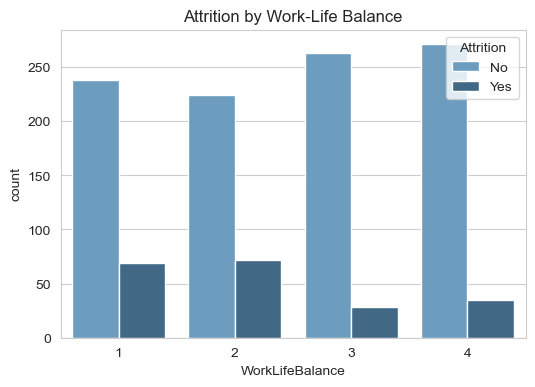

Attrition,No,Yes
WorkLifeBalance,,
1,77.524430,22.475570
2,75.675676,24.324324
3,90.378007,9.621993
4,88.562092,11.437908


In [64]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="WorkLifeBalance", hue="Attrition", palette="Blues_d")
plt.title("Attrition by Work-Life Balance")
plt.show()
pd.crosstab(df["WorkLifeBalance"], df["Attrition"], normalize="index") * 100

**Interpretation**
- Employees reporting poor work-life balance (level 1-2) leave at a higher rate (~22-24%) than those reporting good balance (level 3-4: ~10-11%).
- This suggests employees struggling to balance work and personal life are more likely to leave.

**Business Insight**
  
Work-life balance is clearly linked to attrition. The organization should consider flexible scheduling, 
clearer boundaries around after-hours work, and regular check-ins with teams reporting poor balance scores.

``4. Does time since last promotion affect attrition?``

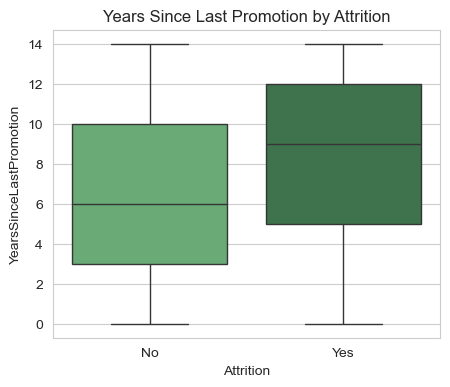

Attrition
No     6.0
Yes    9.0
Name: YearsSinceLastPromotion, dtype: float64

In [66]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Attrition", y="YearsSinceLastPromotion",hue ="Attrition", palette="Greens_d")
plt.title("Years Since Last Promotion by Attrition")
plt.show()
df.groupby("Attrition")["YearsSinceLastPromotion"].median()

**Interpretation**
- Employees who left went longer without a promotion (median 9 years) than those who stayed (median 6 years).
- This suggests slow career growth may push employees to leave.

**Business Insight**

The organization should review promotion cycles and ensure employees have visible career paths. Employees who haven't been promoted in 7+ years could be flagged for a career conversation before they consider leaving.

`` 5. Does Monthly Income affect attrition?``

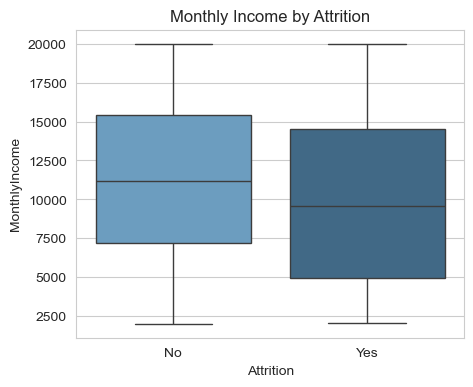

Attrition
No     11164.613636
Yes     9553.514706
Name: MonthlyIncome, dtype: float64

In [69]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", hue="Attrition", palette="Blues_d")
plt.title("Monthly Income by Attrition")
plt.show()
df.groupby("Attrition")["MonthlyIncome"].median()

**Interpretation**
- Employees who left had a lower median income (₹9,554) than those who stayed (₹11,165).
- The gap is noticeable but the two groups still overlap a lot, so income alone doesn't fully explain attrition.

**Business Insight**

Pay may be a contributing factor, but not the main one. The organization should review compensation for lower-income roles, while treating it as a secondary fix alongside workload and career-growth improvements.

## Conclusion

**Five factors stood out as linked to attrition:**

- Overtime — the biggest factor. Employees who work overtime leave almost 5x more often (37.7% vs 7.9%).
- Job Satisfaction — clear pattern. Lower satisfaction means higher attrition.
- Work-Life Balance — similar story. Poor balance means more people leaving.
- Time Since Last Promotion — employees who left waited longer for a promotion (9 years vs 6 years).
- Monthly Income — a smaller factor. Employees who left earned a bit less, but the difference isn't huge.

**Overall:**  Most attrition seems to come from overwork and slow career growth, not pay. Fixing workload and promotion gaps will likely help retention more than raising salaries.

**Recommendations:**

- Reduce overtime by balancing workload or hiring more staff.
- Check in regularly with employees who report low job satisfaction.
- Offer flexible schedules to improve work-life balance.
- Review promotion timelines so employees don't feel stuck.
- Keep compensation fair, but treat it as a secondary fix.